# Experiment Plan and Baseline Alignment

This baseline is adapted to align with the architecture of Jane's CNN to ensure a fair comparison.

## 1. Experiment Plan and Expectations

First, I will train the baseline model with unrotated data, and then I will train the baseline with rotated data. It is expected that the model will perform poorly on the first setup (unrotated), but better on the second (rotated). Ultimately, the equivariant Steerable CNN model is expected to perform the best overall.

Next, I will train the Steerable CNN models. I will mostly follow Jane's code, but I have removed some unnecessary JSON configuration files and fixed a few bugs (with the help of Claude) to make the code neater and cleaner. To specifically investigate the "6 vs. 9" confusion problem, we will compare three models trained on unrotated data: a Standard CNN, a C4 Steerable CNN, and a modified C4 model restricted to the trivial group {e} at the end. A key metric we care about is the model's accuracy in distinguishing between the digits 6 and 9. It is expected that the strictly equivariant C4 model might perform worse in this regard, as it sacrifices specific orientation accuracy to remain symmetric, whereas the Standard CNN and the restricted {e} model will avoid this confusion.

Lastly, we will discuss the principles of whether we should use Steerable CNNs, what extent of symmetry is optimal, and explore a few methods that can mitigate the "6 vs. 9" problem.

---

## 2. Alignment and Modification Details

To ensure that the performance differences in the final comparison can be cleanly attributed to "equivariance" (as outlined in the plan above), the current baseline's parameters have been comprehensively adjusted. All settings are now aligned with Jane's code (C8), with the **only difference being the presence of 'equivariant constraints'**.

### 2.1 Training Settings (Fully Aligned)

| Parameter | Original Baseline | C8 Code | Current Baseline |
|---|---|---|---|
| **Dataset** | Standard MNIST | rotated MNIST (.amat) | **rotated MNIST** |
| **Train transform** | ToTensor + Normalize | pad→resize87→Rot180→resize29→ToTensor | **Identical** |
| **Test transform** | (Two sets, incl. rotated) | pad→ToTensor | **Identical** |
| **Image size** | 28×28 | 29×29 | **29×29** |
| **Batch size** | 64 | 64 | 64 (Unchanged) |
| **Epochs** | 5 | 31 | **31** |
| **Learning rate** | 1e-3 | 5e-5 | **5e-5** |
| **Weight decay** | 1e-4 | 1e-5 | **1e-5** |
| **Optimizer** | Adam | Adam | Adam (Unchanged) |

### 2.2 Architecture (Shape Aligned, Equivariant Constraints Removed)

The sequence of channel numbers, kernel sizes, padding, and downsampling locations **exactly replicate** C8's layer structure:

| Layer | Configuration |
|---|---|
| **block1** | 1 → 24, kernel=7, padding=1 |
| **block2** | 24 → 48, kernel=5, padding=2 |
| **pool1** | AvgPool stride=2 |
| **block3** | 48 → 48, kernel=5, padding=2 |
| **block4** | 48 → 96, kernel=5, padding=2 |
| **pool2** | AvgPool stride=2 |
| **block5** | 96 → 96, kernel=5, padding=2 |
| **block6** | 96 → 64, kernel=5, padding=1 |
| **pool3** | AvgPool stride=1 (5×5 → 1×1) |
| **classifier** | Linear(64,64) → BN → ELU → Linear(64,10) |

*   Replaced the original `F.layer_norm` with `BatchNorm2d` to align with C8's `InnerBatchNorm` (which is essentially BN).
*   Convolutions use `bias=False` (since they are followed by BN), consistent with C8.

### 2.3 Deliberately Unaligned Parts (Core Experimental Variable)

The only difference — **No equivariant constraints**:
*   Use `nn.Conv2d` instead of `enn.R2Conv`.
*   Remove `GeometricTensor` wrapper.
*   Remove `GroupPooling` (use spatial pooling directly).

By running both versions of the code this way, the final accuracy gap can be 100% attributed to the "presence or absence of equivariant structure", without any other confounding variables.

In [8]:
"""
MNIST CNN Baseline - trained WITHOUT rotation (self-contained version)
=======================================================================
Standalone script. Does not depend on any previous cell.

Same architecture and hyperparameters as the aligned C8 baseline, but
trained on STANDARD upright MNIST -- the model never sees a rotated
digit during training. It is then tested on both:
  1. Standard upright MNIST (sanity check, expected ~99%)
  2. Rotated MNIST (expected ~40-55%)
"""

# ============================================================
# 0. Imports + data download
# ============================================================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, Pad, ToTensor, Resize, RandomRotation, InterpolationMode


# ============================================================
# 1. Configuration
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

BATCH_SIZE   = 64
EPOCHS       = 31
LR           = 5e-5
WEIGHT_DECAY = 1e-5


# ============================================================
# 2. Transforms
# ============================================================
# Pad 28x28 -> 29x29 so it fits the architecture.
pad      = Pad((0, 0, 1, 1), fill=0)
totensor = ToTensor()

# Train/Test Unrot: no rotation
transform = Compose([pad, totensor])

# Train/Test Rot: random rotation
resize_up = Resize(87)
resize_dn = Resize(29)
transform_rot = Compose([
    pad, resize_up,
    RandomRotation(180, interpolation=InterpolationMode.BILINEAR, expand=False),
    resize_dn, totensor,
])


# ============================================================
# 3. Model: same architecture as the aligned baseline
# ============================================================
class BaselineCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 24, kernel_size=7, padding=1, bias=False),
            nn.BatchNorm2d(24),
            nn.ReLU(inplace=True),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(24, 48, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.AvgPool2d(kernel_size=5, stride=2, padding=2)

        self.block3 = nn.Sequential(
            nn.Conv2d(48, 48, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(48, 96, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.AvgPool2d(kernel_size=5, stride=2, padding=2)

        self.block5 = nn.Sequential(
            nn.Conv2d(96, 96, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
        )
        self.block6 = nn.Sequential(
            nn.Conv2d(96, 64, kernel_size=5, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.pool3 = nn.AvgPool2d(kernel_size=5, stride=1, padding=0)

        self.fully_net = nn.Sequential(
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ELU(inplace=True),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool1(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool2(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.pool3(x)
        return self.fully_net(x.reshape(x.shape[0], -1))


# ============================================================
# 4. Data loaders
# ============================================================
print("\nLoading datasets...")
# Train: standard upright MNIST
mnist_train = MNIST(root="./data", train=True,  download=True, transform=transform)
# Test set 1: standard upright MNIST (sanity check)
mnist_test_upright = MNIST(root="./data", train=False, download=True, transform=transform)
# Test set 2: standard MNIST rotated
mnist_test_rotated = MNIST(root="./data", train=False, download=True, transform=transform_rot)

print(f"Train (upright): {len(mnist_train)} samples")
print(f"Test  (upright): {len(mnist_test_upright)} samples")
print(f"Test  (rotated): {len(mnist_test_rotated)} samples")

train_loader        = DataLoader(mnist_train,        batch_size=BATCH_SIZE, shuffle=True,
                                 num_workers=2, pin_memory=True)
test_loader_upright = DataLoader(mnist_test_upright, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=2, pin_memory=True)
test_loader_rotated = DataLoader(mnist_test_rotated, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=2, pin_memory=True)


# ============================================================
# 5. Model + optimizer
# ============================================================
model     = BaselineCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")


# ============================================================
# 6. Train / evaluate
# ============================================================
def evaluate_on(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, t in loader:
            x, t = x.to(device), t.to(device)
            pred = model(x).argmax(dim=1)
            correct += (pred == t).sum().item()
            total   += t.size(0)
    return 100.0 * correct / total

print("\n--- Training on plain (upright) MNIST ---")
history_cnn_unrot_up = []
history_cnn_unrot_rot = []

for epoch in tqdm(range(EPOCHS)):
    model.train()
    for x, t in train_loader:
        x, t = x.to(device), t.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(x), t)
        loss.backward()
        optimizer.step()

    # Evaluate on both sets every epoch
    acc_up  = evaluate_on(test_loader_upright)
    acc_rot = evaluate_on(test_loader_rotated)
    history_cnn_unrot_up.append(acc_up)
    history_cnn_unrot_rot.append(acc_rot)

    if epoch % 10 == 0:
        print(f"  epoch {epoch:2d} | upright: {acc_up:6.2f}% | rotated: {acc_rot:6.2f}%")


# ============================================================
# 7. Final results
# ============================================================
final_up  = history_cnn_unrot_up[-1]
final_rot = history_cnn_unrot_rot[-1]

print("\n" + "=" * 55)
print("Final results (CNN baseline, NO rotation in training)")
print("=" * 55)
print(f"  Standard (upright) MNIST test:  {final_up:6.2f}%")
print(f"  Rotated MNIST test:             {final_rot:6.2f}%")
print(f"  Accuracy drop:                  {final_up - final_rot:6.2f} pp")
print("=" * 55)


# ============================================================
# 8. Save checkpoint
# ============================================================
os.makedirs("models", exist_ok=True)
ckpt_path = "models/baseline_cnn_no_rotation.pth"
torch.save(model.state_dict(), ckpt_path)
print(f"Checkpoint saved to {ckpt_path}")

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB

Loading datasets...
Train (upright): 60000 samples
Test  (upright): 10000 samples
Test  (rotated): 10000 samples
Model parameters: 592,466

--- Training on plain (upright) MNIST ---


  3%|▎         | 1/31 [00:09<04:31,  9.06s/it]

  epoch  0 | upright:  99.00% | rotated:  42.02%


 35%|███▌      | 11/31 [01:39<02:59,  8.99s/it]

  epoch 10 | upright:  99.32% | rotated:  44.13%


 68%|██████▊   | 21/31 [03:08<01:29,  8.95s/it]

  epoch 20 | upright:  99.32% | rotated:  45.50%


100%|██████████| 31/31 [04:39<00:00,  9.02s/it]

  epoch 30 | upright:  99.35% | rotated:  46.68%

Final results (CNN baseline, NO rotation in training)
  Standard (upright) MNIST test:   99.35%
  Rotated MNIST test:              46.68%
  Accuracy drop:                   52.67 pp
Checkpoint saved to models/baseline_cnn_no_rotation.pth


In [9]:
# Cell 2: Same architecture, trained WITH rotation augmentation
# (assumes Cell 1 has been run)

import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, Pad, ToTensor, Resize, RandomRotation, InterpolationMode
from torch.utils.data import DataLoader
from tqdm import tqdm

pad = Pad((0, 0, 1, 1), fill=0)
totensor = ToTensor()
resize_up = Resize(87)
resize_dn = Resize(29)
transform_rot = Compose([
    pad, resize_up,
    RandomRotation(180, interpolation=InterpolationMode.BILINEAR, expand=False),
    resize_dn, totensor,
])

# Swap training set to standard MNIST + the rotation augmentation
mnist_train_rot  = MNIST(root="./data", train=True, download=True, transform=transform_rot)
train_loader_rot = DataLoader(mnist_train_rot, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=2, pin_memory=(device.type == 'cuda'))

# Fresh model (same BaselineCNN class, fresh weights)
model_rot = BaselineCNN().to(device)
optimizer = torch.optim.Adam(model_rot.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.CrossEntropyLoss()

def evaluate_model_rot(loader):
    model_rot.eval()
    correct = total = 0
    with torch.no_grad():
        for x, t in loader:
            x, t = x.to(device), t.to(device)
            pred = model_rot(x).argmax(dim=1)
            correct += (pred == t).sum().item()
            total   += t.size(0)
    return 100.0 * correct / total

print("\n--- Training with rotation augmentation ---")
history_cnn_rot_up = []
history_cnn_rot_rot = []

for epoch in tqdm(range(EPOCHS)):
    model_rot.train()
    for x, t in train_loader_rot:
        x, t = x.to(device), t.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model_rot(x), t)
        loss.backward()
        optimizer.step()

    # Evaluate on both sets every epoch
    acc_up = evaluate_model_rot(test_loader_upright)
    acc_rot = evaluate_model_rot(test_loader_rotated)
    history_cnn_rot_up.append(acc_up)
    history_cnn_rot_rot.append(acc_rot)

    if epoch % 10 == 0:
        print(f"  epoch {epoch:2d} | upright acc: {acc_up:.2f}% | rotated acc: {acc_rot:.2f}%")

print(f"\nFinal rotated test accuracy: {history_cnn_rot_rot[-1]:.2f}%")
torch.save(model_rot.state_dict(), "models/baseline_cnn_rotation.pth")


--- Training with rotation augmentation ---


  3%|▎         | 1/31 [00:19<09:34, 19.17s/it]

  epoch  0 | upright acc: 81.95% | rotated acc: 90.76%


 35%|███▌      | 11/31 [03:32<06:26, 19.34s/it]

  epoch 10 | upright acc: 93.83% | rotated acc: 95.73%


 68%|██████▊   | 21/31 [06:43<03:10, 19.02s/it]

  epoch 20 | upright acc: 95.43% | rotated acc: 96.72%


100%|██████████| 31/31 [09:55<00:00, 19.21s/it]

  epoch 30 | upright acc: 96.53% | rotated acc: 96.83%

Final rotated test accuracy: 96.83%


In [10]:
# =============================================================================
# =====================  CELL 3  ==============================================
# =====  Setup + parameterized SteerableCNN class + C4 training run    =======
# =============================================================================

import os
import torch
import torch.nn as nn
from tqdm import tqdm
import warnings

# Suppress the deprecation warnings from e2cnn for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

# --- install e2cnn if missing -------------------------------------------------
import subprocess, sys
try:
    import e2cnn  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "e2cnn"])

from e2cnn import gspaces
from e2cnn import nn as enn  # alias to avoid clashing with torch.nn


# --- parameterized SteerableCNN ---------------------------------------------
# Identical to Jane's C8 model, just with N as a constructor argument so we
# can sweep over C4, C8, C12, C16 by changing one number.
class CNSteerableCNN(torch.nn.Module):
    """C_N-equivariant Steerable CNN. N is the order of the cyclic group."""

    def __init__(self, N, n_classes=10):
        super().__init__()
        self.N = N
        self.r2_act = gspaces.Rot2dOnR2(N=N)

        # input: grayscale -> trivial representation
        in_type = enn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        self.input_type = in_type

        # block 1
        out_type = enn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block1 = enn.SequentialModule(
            enn.MaskModule(in_type, 29, margin=1),
            enn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 2
        in_type  = self.block1.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block2 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool1 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        # block 3
        in_type  = self.block2.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block3 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 4
        in_type  = self.block3.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block4 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool2 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        # block 5
        in_type  = self.block4.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block5 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 6
        in_type  = self.block5.out_type
        out_type = enn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        self.block6 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool3 = enn.PointwiseAvgPoolAntialiased(
            out_type, sigma=0.66, stride=1, padding=0,
        )

        # group pool -> rotation-invariant features
        self.gpool = enn.GroupPooling(out_type)
        c = self.gpool.out_type.size

        self.fully_net = torch.nn.Sequential(
            torch.nn.Linear(c, 64),
            torch.nn.BatchNorm1d(64),
            torch.nn.ELU(inplace=True),
            torch.nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = enn.GeometricTensor(x, self.input_type)
        x = self.block1(x); x = self.block2(x); x = self.pool1(x)
        x = self.block3(x); x = self.block4(x); x = self.pool2(x)
        x = self.block5(x); x = self.block6(x); x = self.pool3(x)
        x = self.gpool(x).tensor
        return self.fully_net(x.reshape(x.shape[0], -1))


# --- reusable training function ---------------------------------------------
# Returns (trained_model, final_test_accuracy). Saves a checkpoint named
# c{N}_steerable_cnn.pth.
def train_steerable(N, epochs=EPOCHS):
    model = CNSteerableCNN(N=N).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.CrossEntropyLoss()

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nC{N} SteerableCNN | parameters: {n_params:,}")

    def evaluate(loader):
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, t in loader:    # rotated MNIST test, from Cell 1
                x, t = x.to(device), t.to(device)
                pred = model(x).argmax(dim=1)
                correct += (pred == t).sum().item()
                total   += t.size(0)
        return 100.0 * correct / total

    hist_up = []
    hist_rot = []

    print(f"--- Training C{N} ---")
    for epoch in tqdm(range(epochs)):
        model.train()
        for x, t in train_loader_rot:           # rotation-augmented, from Cell 2
            x, t = x.to(device), t.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), t)
            loss.backward()
            optimizer.step()

        # Evaluate on both sets every epoch
        acc_up = evaluate(test_loader_upright)
        acc_rot = evaluate(test_loader_rotated)
        hist_up.append(acc_up)
        hist_rot.append(acc_rot)

        if epoch % 10 == 0:
            print(f"  epoch {epoch:2d} | upright acc: {acc_up:.3f}% | rotated acc: {acc_rot:.3f}%")

    final_acc = hist_rot[-1]
    print(f"Final C{N} accuracy: {final_acc:.3f}%")

    os.makedirs("models", exist_ok=True)
    ckpt_path = f"models/c{N}_steerable_cnn.pth"
    torch.save(model.state_dict(), ckpt_path)
    print(f"Saved to {ckpt_path}")
    return model, final_acc, hist_up, hist_rot


# --- run the C4 experiment ---------------------------------------------------
model_c4, acc_c4, history_c4_rot_up, history_c4_rot_rot = train_steerable(N=4)


C4 SteerableCNN | parameters: 1,037,619
--- Training C4 ---


  3%|▎         | 1/31 [00:19<09:38, 19.28s/it]

  epoch  0 | upright acc: 92.650% | rotated acc: 95.580%


 35%|███▌      | 11/31 [03:29<06:22, 19.10s/it]

  epoch 10 | upright acc: 94.820% | rotated acc: 97.310%


 68%|██████▊   | 21/31 [06:42<03:11, 19.19s/it]

  epoch 20 | upright acc: 93.440% | rotated acc: 97.460%


100%|██████████| 31/31 [09:55<00:00, 19.20s/it]

  epoch 30 | upright acc: 94.220% | rotated acc: 97.600%
Final C4 accuracy: 97.600%
Saved to models/c4_steerable_cnn.pth


In [11]:
import torch
import torch.nn as nn
from tqdm import tqdm

print("--- Training C4 Steerable CNN on UNROTATED data ---")
model_c4_unrot = CNSteerableCNN(N=4).to(device)
optimizer_c4_unrot = torch.optim.Adam(model_c4_unrot.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = nn.CrossEntropyLoss()

def evaluate_c4_unrot(loader):
    model_c4_unrot.eval()
    correct = total = 0
    with torch.no_grad():
        for x, t in loader:
            x, t = x.to(device), t.to(device)
            pred = model_c4_unrot(x).argmax(dim=1)
            correct += (pred == t).sum().item()
            total += t.size(0)
    return 100.0 * correct / total

history_c4_unrot_up = []
history_c4_unrot_rot = []

for epoch in tqdm(range(EPOCHS)):
    model_c4_unrot.train()
    for x, t in train_loader:  # Unrotated train set
        x, t = x.to(device), t.to(device)
        optimizer_c4_unrot.zero_grad()
        loss = loss_fn(model_c4_unrot(x), t)
        loss.backward()
        optimizer_c4_unrot.step()

    # Evaluate on both test sets every epoch
    acc_up = evaluate_c4_unrot(test_loader_upright)
    acc_rot = evaluate_c4_unrot(test_loader_rotated)
    history_c4_unrot_up.append(acc_up)
    history_c4_unrot_rot.append(acc_rot)

    if epoch % 10 == 0:
        print(f"  epoch {epoch:2d} | unrotated test acc: {acc_up:.3f}% | rotated test acc: {acc_rot:.3f}%")

print(f"Final C4 Steerable CNN (Unrotated) accuracy: {history_c4_unrot_up[-1]:.3f}%")

--- Training C4 Steerable CNN on UNROTATED data ---


  3%|▎         | 1/31 [00:17<08:31, 17.04s/it]

  epoch  0 | unrotated test acc: 97.060% | rotated test acc: 86.220%


 35%|███▌      | 11/31 [03:07<05:43, 17.18s/it]

  epoch 10 | unrotated test acc: 97.960% | rotated test acc: 86.350%


 68%|██████▊   | 21/31 [05:59<02:50, 17.08s/it]

  epoch 20 | unrotated test acc: 97.940% | rotated test acc: 87.400%


100%|██████████| 31/31 [08:50<00:00, 17.10s/it]

  epoch 30 | unrotated test acc: 97.590% | rotated test acc: 86.510%
Final C4 Steerable CNN (Unrotated) accuracy: 97.590%



Evaluating all 4 models on both Unrotated and Rotated test sets...


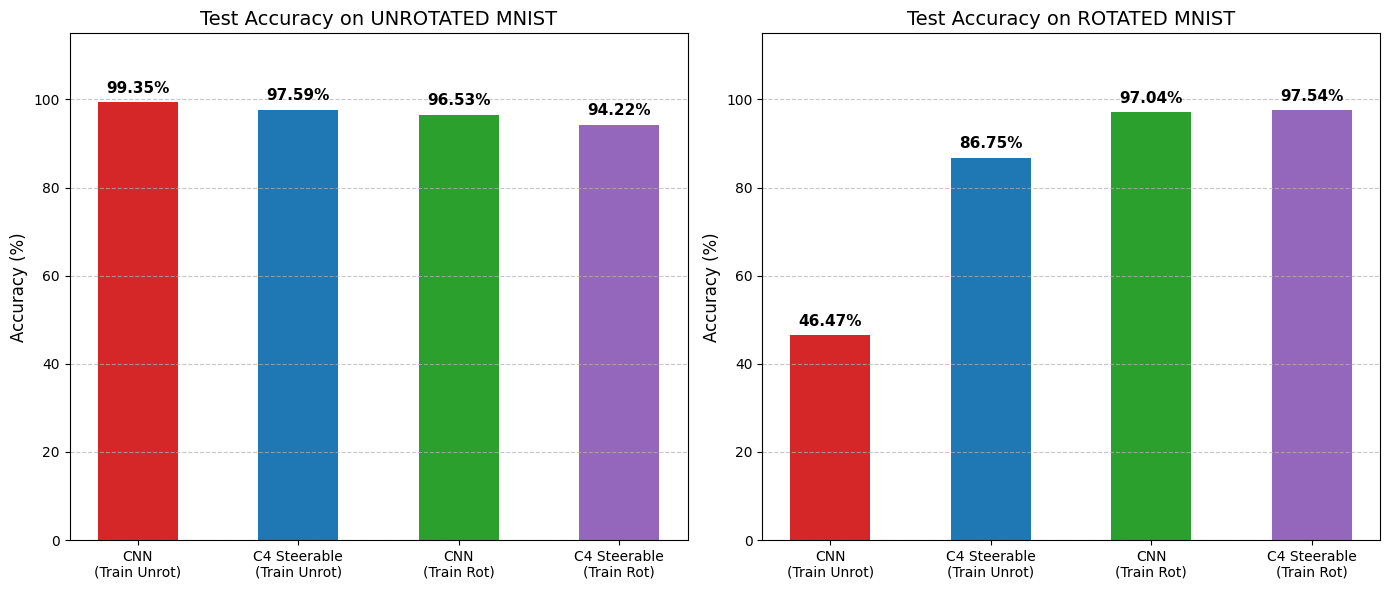

In [12]:
import matplotlib.pyplot as plt
import torch

print("\nEvaluating all 4 models on both Unrotated and Rotated test sets...")

def get_acc(m, loader):
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for x, t in loader:
            x, t = x.to(device), t.to(device)
            pred = m(x).argmax(dim=1)
            correct += (pred == t).sum().item()
            total += t.size(0)
    return 100.0 * correct / total

# Evaluate Model 1: CNN (Train Unrot)
acc_cnn_unrot_up = get_acc(model, test_loader_upright)
acc_cnn_unrot_rot = get_acc(model, test_loader_rotated)

# Evaluate Model 2: CNN (Train Rot)
acc_cnn_rot_up = get_acc(model_rot, test_loader_upright)
acc_cnn_rot_rot = get_acc(model_rot, test_loader_rotated)

# Evaluate Model 3: C4 Steerable CNN (Train Rot)
acc_c4_rot_up = get_acc(model_c4, test_loader_upright)
acc_c4_rot_rot = get_acc(model_c4, test_loader_rotated)

# Evaluate Model 4: C4 Steerable CNN (Train Unrot)
acc_c4_unrot_up = get_acc(model_c4_unrot, test_loader_upright)
acc_c4_unrot_rot = get_acc(model_c4_unrot, test_loader_rotated)

models_labels = ['CNN\n(Train Unrot)', 'C4 Steerable\n(Train Unrot)', 'CNN\n(Train Rot)', 'C4 Steerable\n(Train Rot)']
accs_up = [acc_cnn_unrot_up, acc_c4_unrot_up, acc_cnn_rot_up, acc_c4_rot_up]
accs_rot = [acc_cnn_unrot_rot, acc_c4_unrot_rot, acc_cnn_rot_rot, acc_c4_rot_rot]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd']

# Subplot 1: Unrotated
bars1 = ax1.bar(models_labels, accs_up, color=colors, width=0.5)
ax1.set_title('Test Accuracy on UNROTATED MNIST', fontsize=14)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_ylim(0, 115)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Subplot 2: Rotated
bars2 = ax2.bar(models_labels, accs_rot, color=colors, width=0.5)
ax2.set_title('Test Accuracy on ROTATED MNIST', fontsize=14)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_ylim(0, 115)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### Per-Epoch Accuracy Plot
*Note: To run the cell below, ensure you have modified your training loops to record the accuracy for every epoch into the respective history lists.*

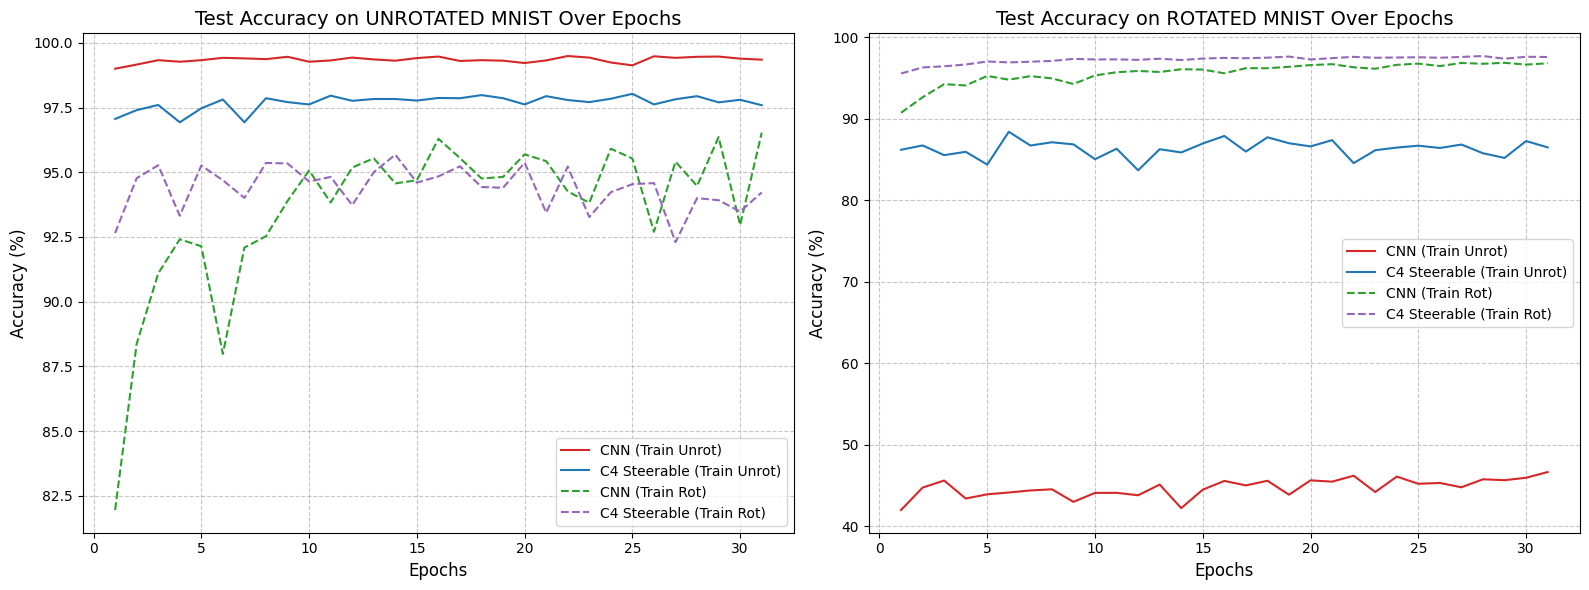

In [13]:
import matplotlib.pyplot as plt

# Fallback to zeros if the training loops haven't saved these histories yet.
def get_hist(name):
    return globals().get(name, [0] * EPOCHS)

history_cnn_unrot_up = get_hist('history_cnn_unrot_up')
history_cnn_unrot_rot = get_hist('history_cnn_unrot_rot')
history_cnn_rot_up = get_hist('history_cnn_rot_up')
history_cnn_rot_rot = get_hist('history_cnn_rot_rot')
history_c4_rot_up = get_hist('history_c4_rot_up')
history_c4_rot_rot = get_hist('history_c4_rot_rot')
history_c4_unrot_up = get_hist('history_c4_unrot_up')
history_c4_unrot_rot = get_hist('history_c4_unrot_rot')

epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Unrotated Test Set Accuracy
ax1.plot(epochs_range, history_cnn_unrot_up, label='CNN (Train Unrot)', color='#d62728', linestyle='-')
ax1.plot(epochs_range, history_c4_unrot_up, label='C4 Steerable (Train Unrot)', color='#1f77b4', linestyle='-')
ax1.plot(epochs_range, history_cnn_rot_up, label='CNN (Train Rot)', color='#2ca02c', linestyle='--')
ax1.plot(epochs_range, history_c4_rot_up, label='C4 Steerable (Train Rot)', color='#9467bd', linestyle='--')
ax1.set_title('Test Accuracy on UNROTATED MNIST Over Epochs', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Rotated Test Set Accuracy
ax2.plot(epochs_range, history_cnn_unrot_rot, label='CNN (Train Unrot)', color='#d62728', linestyle='-')
ax2.plot(epochs_range, history_c4_unrot_rot, label='C4 Steerable (Train Unrot)', color='#1f77b4', linestyle='-')
ax2.plot(epochs_range, history_cnn_rot_rot, label='CNN (Train Rot)', color='#2ca02c', linestyle='--')
ax2.plot(epochs_range, history_c4_rot_rot, label='C4 Steerable (Train Rot)', color='#9467bd', linestyle='--')
ax2.set_title('Test Accuracy on ROTATED MNIST Over Epochs', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

It is verified that training an ENN with rotated data performs better than a regular CNN. Next, we will investigate the 6 vs 9 problem, which means the model might behave poorly in distinguishing between 6 and 9. To better demonstrate this problem, we will train a C4 ENN on unrotated data and compare it with a normal CNN and a refined C4->{e} network.

In [14]:
# =============================================================================
# =====================  CELL 4  ==============================================
# =====  Standard CNN (Trained on Unrotated, Tested on Unrotated)       =======
# =============================================================================

print("--- Training Standard CNN on UNROTATED data ---")
model_cnn_unrot = BaselineCNN().to(device)
optimizer = torch.optim.Adam(model_cnn_unrot.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = nn.CrossEntropyLoss()

def evaluate_cnn_unrot():
    model_cnn_unrot.eval()
    correct = total = 0
    with torch.no_grad():
        for x, t in test_loader_upright:  # Unrotated test set
            x, t = x.to(device), t.to(device)
            pred = model_cnn_unrot(x).argmax(dim=1)
            correct += (pred == t).sum().item()
            total += t.size(0)
    return 100.0 * correct / total

for epoch in tqdm(range(EPOCHS)):
    model_cnn_unrot.train()
    for x, t in train_loader:  # Unrotated train set
        x, t = x.to(device), t.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model_cnn_unrot(x), t)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        print(f"  epoch {epoch:2d} | unrotated test acc: {evaluate_cnn_unrot():.3f}%")

acc_cnn_unrot = evaluate_cnn_unrot()
print(f"Final Standard CNN (Unrotated) accuracy: {acc_cnn_unrot:.3f}%")

--- Training Standard CNN on UNROTATED data ---


  3%|▎         | 1/31 [00:06<03:19,  6.64s/it]

  epoch  0 | unrotated test acc: 99.010%


 35%|███▌      | 11/31 [01:02<01:55,  5.77s/it]

  epoch 10 | unrotated test acc: 99.290%


 68%|██████▊   | 21/31 [01:57<00:56,  5.68s/it]

  epoch 20 | unrotated test acc: 99.480%


100%|██████████| 31/31 [02:52<00:00,  5.56s/it]

  epoch 30 | unrotated test acc: 99.410%


Final Standard CNN (Unrotated) accuracy: 99.410%


In [15]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import e2cnn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "e2cnn"])

from e2cnn import gspaces
from e2cnn import nn as enn

class CNSteerableCNN(torch.nn.Module):
    """C_N-equivariant Steerable CNN. N is the order of the cyclic group."""

    def __init__(self, N, n_classes=10):
        super().__init__()
        self.N = N
        self.r2_act = gspaces.Rot2dOnR2(N=N)

        # input: grayscale -> trivial representation
        in_type = enn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        self.input_type = in_type

        # block 1
        out_type = enn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block1 = enn.SequentialModule(
            enn.MaskModule(in_type, 29, margin=1),
            enn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 2
        in_type  = self.block1.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block2 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool1 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        # block 3
        in_type  = self.block2.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block3 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 4
        in_type  = self.block3.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block4 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool2 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        # block 5
        in_type  = self.block4.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block5 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        # block 6
        in_type  = self.block5.out_type
        out_type = enn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        self.block6 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool3 = enn.PointwiseAvgPoolAntialiased(
            out_type, sigma=0.66, stride=1, padding=0,
        )

        # group pool -> rotation-invariant features
        self.gpool = enn.GroupPooling(out_type)
        c = self.gpool.out_type.size

        self.fully_net = torch.nn.Sequential(
            torch.nn.Linear(c, 64),
            torch.nn.BatchNorm1d(64),
            torch.nn.ELU(inplace=True),
            torch.nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = enn.GeometricTensor(x, self.input_type)
        x = self.block1(x); x = self.block2(x); x = self.pool1(x)
        x = self.block3(x); x = self.block4(x); x = self.pool2(x)
        x = self.block5(x); x = self.block6(x); x = self.pool3(x)
        x = self.gpool(x).tensor
        return self.fully_net(x.reshape(x.shape[0], -1))

# =============================================================================
# =====================  CELL 5  ==============================================
# =====  C4 Steerable CNN (Trained on Unrotated, Tested on Unrotated)   =======
# =============================================================================

print("--- Training C4 Steerable CNN on UNROTATED data ---")
model_c4_unrot = CNSteerableCNN(N=4).to(device)
optimizer = torch.optim.Adam(model_c4_unrot.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = nn.CrossEntropyLoss()

def evaluate_c4_unrot():
    model_c4_unrot.eval()
    correct = total = 0
    with torch.no_grad():
        for x, t in test_loader_upright:  # Unrotated test set
            x, t = x.to(device), t.to(device)
            pred = model_c4_unrot(x).argmax(dim=1)
            correct += (pred == t).sum().item()
            total += t.size(0)
    return 100.0 * correct / total

for epoch in tqdm(range(EPOCHS)):
    model_c4_unrot.train()
    for x, t in train_loader:  # Unrotated train set
        x, t = x.to(device), t.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model_c4_unrot(x), t)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        print(f"  epoch {epoch:2d} | unrotated test acc: {evaluate_c4_unrot():.3f}%")

acc_c4_unrot = evaluate_c4_unrot()
print(f"Final C4 Steerable CNN (Unrotated) accuracy: {acc_c4_unrot:.3f}%")


--- Training C4 Steerable CNN on UNROTATED data ---


  3%|▎         | 1/31 [00:14<07:15, 14.51s/it]

  epoch  0 | unrotated test acc: 96.770%


 35%|███▌      | 11/31 [02:29<04:35, 13.78s/it]

  epoch 10 | unrotated test acc: 97.700%


 68%|██████▊   | 21/31 [04:43<02:15, 13.60s/it]

  epoch 20 | unrotated test acc: 97.710%


100%|██████████| 31/31 [06:57<00:00, 13.48s/it]

  epoch 30 | unrotated test acc: 97.960%


Final C4 Steerable CNN (Unrotated) accuracy: 97.960%


In [16]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm
import warnings

# Suppress UserWarning from underlying deprecated e2cnn code
warnings.filterwarnings("ignore", category=UserWarning)

# Ensure e2cnn is installed and imported
try:
    import e2cnn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "e2cnn"])

from e2cnn import gspaces
from e2cnn import nn as enn

class RestrictedSteerableCNN(torch.nn.Module):
    """C_N-equivariant for blocks 1-5, restricted to {e} (trivial group) for block 6."""

    def __init__(self, N, n_classes=10):
        super().__init__()
        self.N = N
        self.r2_act = gspaces.Rot2dOnR2(N=N)

        # input: grayscale -> trivial representation
        in_type = enn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        self.input_type = in_type

        # ===== blocks 1-5: Exactly the same as original, fully C_N equivariant =====
        out_type = enn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block1 = enn.SequentialModule(
            enn.MaskModule(in_type, 29, margin=1),
            enn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        in_type  = self.block1.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block2 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool1 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type  = self.block2.out_type
        out_type = enn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block3 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )

        in_type  = self.block3.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block4 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool2 = enn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type  = self.block4.out_type
        out_type = enn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block5 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        # ⬆️ Up to here, everything is C_N equivariant, identical to the original code

        # ===== Restriction point: reduce from C_N to {e} =====
        # id=1 means restricting to the trivial group containing only the identity element
        # (i.e., no rotation equivariance required)
        self.restrict = enn.RestrictionModule(out_type, id=1)
        in_type = self.restrict.out_type   # New type after restriction (in {e} gspace)

        # After restriction, the gspace changes, requiring the new gspace for subsequent FieldTypes
        small_act = in_type.gspace          # This is the gspace corresponding to {e}

        # ===== block 6: Working on {e} (mathematically equivalent to a standard convolution) =====
        out_type = enn.FieldType(small_act, 64 * [small_act.regular_repr])
        self.block6 = enn.SequentialModule(
            enn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            enn.InnerBatchNorm(out_type),
            enn.ReLU(out_type, inplace=True),
        )
        self.pool3 = enn.PointwiseAvgPoolAntialiased(
            out_type, sigma=0.66, stride=1, padding=0,
        )

        # GroupPooling on {e} is a trivial operation (group has only 1 element, nothing to pool)
        # Keeping it just to maintain consistent code structure with the original
        self.gpool = enn.GroupPooling(out_type)
        c = self.gpool.out_type.size

        self.fully_net = torch.nn.Sequential(
            torch.nn.Linear(c, 64),
            torch.nn.BatchNorm1d(64),
            torch.nn.ELU(inplace=True),
            torch.nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = enn.GeometricTensor(x, self.input_type)
        x = self.block1(x); x = self.block2(x); x = self.pool1(x)
        x = self.block3(x); x = self.block4(x); x = self.pool2(x)
        x = self.block5(x)
        x = self.restrict(x)         # ← Key new line: restrict to {e} here
        x = self.block6(x); x = self.pool3(x)
        x = self.gpool(x).tensor
        return self.fully_net(x.reshape(x.shape[0], -1))

def train_restricted(N, epochs=EPOCHS):
    model = RestrictedSteerableCNN(N=N).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.CrossEntropyLoss()

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nRestricted C{N}→{{e}} | parameters: {n_params:,}")

    def evaluate(loader):
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for x, t in loader:
                x, t = x.to(device), t.to(device)
                pred = model(x).argmax(dim=1)
                correct += (pred == t).sum().item()
                total   += t.size(0)
        return 100.0 * correct / total

    print(f"--- Training Restricted C{N}→{{e}} on UPRIGHT MNIST ---")
    for epoch in tqdm(range(epochs)):
        model.train()
        for x, t in train_loader:              # ← Changed here! Originally train_loader_rot
            x, t = x.to(device), t.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), t)
            loss.backward()
            optimizer.step()
        if epoch % 10 == 0:
            acc_up  = evaluate(test_loader_upright)
            acc_rot = evaluate(test_loader_rotated)
            print(f"  epoch {epoch:2d} | upright: {acc_up:.2f}% | rotated: {acc_rot:.2f}%")

    final_up  = evaluate(test_loader_upright)
    final_rot = evaluate(test_loader_rotated)
    print(f"\nFinal | upright: {final_up:.2f}% | rotated: {final_rot:.2f}%")

    os.makedirs("models", exist_ok=True)
    ckpt_path = f"models/c{N}_restricted_e_upright.pth"
    torch.save(model.state_dict(), ckpt_path)
    print(f"Saved to {ckpt_path}")
    return model, final_up, final_rot

# --- Run restricted C4 experiment ---
model_res, acc_up, acc_rot = train_restricted(N=4)



Restricted C4→{e} | parameters: 1,037,619
--- Training Restricted C4→{e} on UPRIGHT MNIST ---


  3%|▎         | 1/31 [00:17<08:30, 17.01s/it]

  epoch  0 | upright: 99.14% | rotated: 44.31%


 35%|███▌      | 11/31 [02:34<04:52, 14.62s/it]

  epoch 10 | upright: 99.42% | rotated: 45.72%


 68%|██████▊   | 21/31 [04:51<02:24, 14.43s/it]

  epoch 20 | upright: 99.42% | rotated: 46.89%


100%|██████████| 31/31 [07:08<00:00, 13.81s/it]

  epoch 30 | upright: 99.38% | rotated: 46.06%



Final | upright: 99.38% | rotated: 45.59%
Saved to models/c4_restricted_e_upright.pth


=== 6 vs 9 Confusion Probability on UPRIGHT Test Set ===
(Trained on Unrotated Data)

Standard CNN        :    0 / 1967 ( 0.00%)
C4 Steerable CNN    :  100 / 1967 ( 5.08%)
Restricted C4->{e}  :    0 / 1967 ( 0.00%)


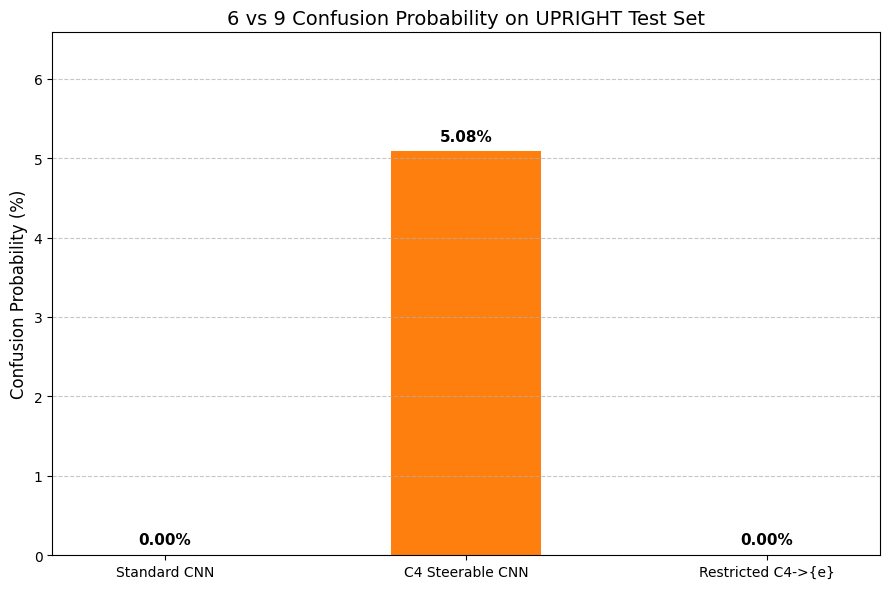

In [17]:
import matplotlib.pyplot as plt

def evaluate_69_confusion(model, loader, model_name):
    model.eval()
    confusions = 0
    total_6_and_9 = 0

    with torch.no_grad():
        for x, t in loader:
            x, t = x.to(device), t.to(device)
            pred = model(x).argmax(dim=1)

            # Find samples where the true label is 6 or 9
            mask_6 = (t == 6)
            mask_9 = (t == 9)
            total_6_and_9 += (mask_6.sum() + mask_9.sum()).item()

            # Count confusions: true 6 predicted as 9, true 9 predicted as 6
            confused_6_as_9 = (mask_6 & (pred == 9)).sum().item()
            confused_9_as_6 = (mask_9 & (pred == 6)).sum().item()

            confusions += (confused_6_as_9 + confused_9_as_6)

    prob = confusions / total_6_and_9 if total_6_and_9 > 0 else 0
    print(f"{model_name:<20}: {confusions:>4} / {total_6_and_9} ({prob*100:>5.2f}%)")
    return prob * 100

print("=== 6 vs 9 Confusion Probability on UPRIGHT Test Set ===")
print("(Trained on Unrotated Data)\n")

prob_cnn = evaluate_69_confusion(model_cnn_unrot, test_loader_upright, "Standard CNN")
prob_c4  = evaluate_69_confusion(model_c4_unrot, test_loader_upright, "C4 Steerable CNN")
prob_res = evaluate_69_confusion(model_res, test_loader_upright, "Restricted C4->{e}")

# Plot the histogram (Bar Chart) for visual comparison
models = ['Standard CNN', 'C4 Steerable CNN', 'Restricted C4->{e}']
probs = [prob_cnn, prob_c4, prob_res]

plt.figure(figsize=(9, 6))
bars = plt.bar(models, probs, color=['#1f77b4', '#ff7f0e', '#2ca02c'], width=0.5)
plt.title('6 vs 9 Confusion Probability on UPRIGHT Test Set', fontsize=14)
plt.ylabel('Confusion Probability (%)', fontsize=12)
plt.ylim(0, max(probs) + 1.5 if max(probs) > 0 else 10)

# Add probability values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
